/usr/local/lib/python3.13/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Error fetching California housing dataset: HTTP Error 403: Forbidden. Attempting to load from local CSVs.
California housing dataset loaded from local CSVs.
Dataset shape: (20000, 11)

Columns:
Index(['longitude', 'latitude', 'HouseAge', 'total_rooms', 'total_bedrooms',
       'population', 'households', 'MedInc', 'MedHouseVal', 'AveRooms',
       'AveOccup'],
      dtype='object')

Missing values:
longitude         0
latitude          0
HouseAge          0
total_rooms       0
total_bedrooms    0
population        0
households        0
MedInc            0
MedHouseVal       0
AveRooms          0
AveOccup          0
dtype: int64
Selected Features:
   MedInc  HouseAge   AveRooms  AveOccup
0  1.4936      15.0  11.889831  2.150424
1  1.8200      19.0  16.522678  2.438445
2  1.6509      17.0   6.153846  2.846154
3  3.1917      14.0   6.641593  2.278761
4  1.9250      20.0   5.549618  2.381679

Target:
0    66900.0
1    80100.0
2    85700.0
3    73400.0
4    65500.0
Name: MedHouseVal, dtype: 

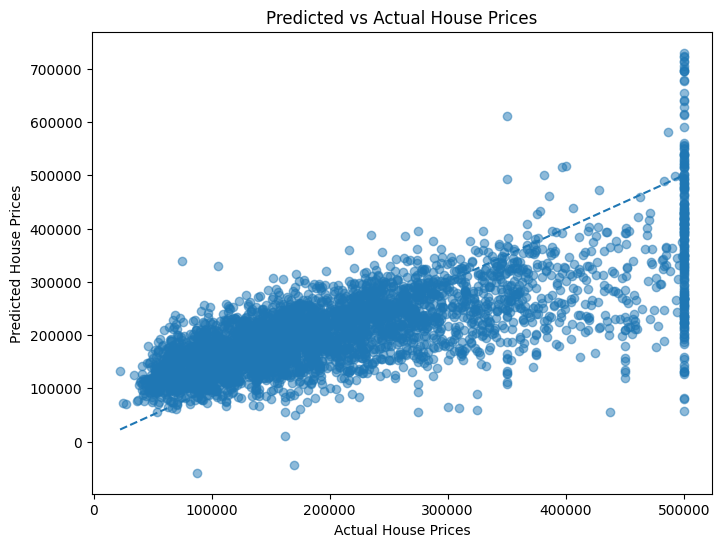

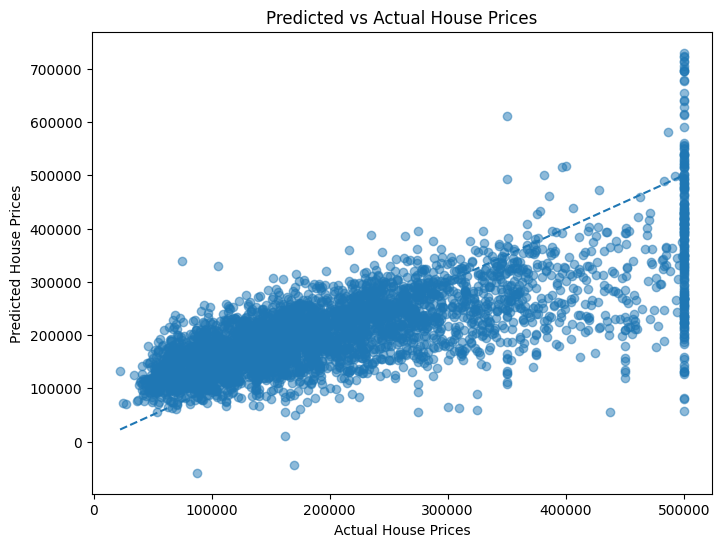

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from urllib.error import HTTPError # Import HTTPError to catch specifically

try:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    print("California housing dataset fetched successfully.")
except HTTPError as e:
    print(f"Error fetching California housing dataset: {e}. Attempting to load from local CSVs.")
    try:
        train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
        test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')
        df = pd.concat([train_df, test_df], ignore_index=True)

        # Rename columns to match sklearn's fetch_california_housing output for consistency
        df.rename(columns={
            'median_income': 'MedInc',
            'housing_median_age': 'HouseAge',
            'median_house_value': 'MedHouseVal'
        }, inplace=True)

        # Calculate AveRooms and AveOccup as done in the original dataset
        df['AveRooms'] = df['total_rooms'] / df['households']
        df['AveOccup'] = df['population'] / df['households']

        print("California housing dataset loaded from local CSVs.")
    except Exception as local_load_error:
        print(f"Failed to load dataset from local CSVs either: {local_load_error}")
        raise e # Re-raise the original HTTPError if local load also fails

df.head()
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

df.describe()

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']

X = df[features]
y = df['MedHouseVal']

print("Selected Features:")
print(X.head())

print("\nTarget:")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Predicted vs Actual House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Predicted vs Actual House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [5]:
print("=" * 40)
print("LINEAR REGRESSION RESULTS")
print("=" * 40)

print(f"Number of features: {len(features)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 40)

LINEAR REGRESSION RESULTS
Number of features: 4
Training samples: 16000
Testing samples: 4000
RMSE: 80805.7155
R² Score: 0.5245


R² tells us how well our model explains differences in house prices. An R² score of about 0.55 means that our selected features explain around 55% of the variation in house prices. The remaining 45% is influenced by other factors that our model does not include, such as location, number of bedrooms, and other property characteristics. Therefore, the model is useful for making predictions, but there is still significant room for improvement